# Additional testing cases: horizontal table

## Set autoreload, library importing, logging, and environment 

In [11]:
# Enable autoreload to automatically pick up changes in local modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
# Import libraries
import logging
from pathlib import Path
from IPython.display import display, Markdown, Image

from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.datamodel.base_models import InputFormat

from doc_agent.utils.logger import setup_logger
from doc_agent.ingestion.docling_parser import parse_document
from utils.extract_page import extract_page_image
from utils.encode_image import encode_image_to_base64


# Configure logging
# Local notebook logger
logger = setup_logger(
    name="004_additional_testing_cases_2", 
    level=logging.INFO,
    log_file="notebook_experiments.log",
    log_dir=Path.cwd() / "logs"
)

logger.info("Logging system successfully initialized.")

2026-05-05 18:23:11 |     INFO | 004_additional_testing_cases_2:2386461100.py:25 - Logging system successfully initialized.


## Workspace & Path Configuration
Setting up relative paths for raw documents, interim data (extracted images and Markdown), and processed outputs.

In [13]:
# Paths relative to the notebook's location (notebooks/data/...)
notebook_root = Path.cwd()
# Path to the pdf-file
pdf_file = notebook_root / "data" / "01_raw" / "one_page_horizontal_table.pdf"
logger.info(f"Path to the pdf-file: {pdf_file}")
# Path to the raw md-file
raw_markdown_file = notebook_root / "data" / "02_interim" / "one_page_horizontal_table.md"
logger.info(f"Path to the md-file: {raw_markdown_file}")
# Path to the extracted page images
page_images_dir = notebook_root / "data" / "02_interim" / "page_images" 
logger.info(f"Path to the page images directory: {page_images_dir}")

docling_images_dir = notebook_root / "data" / "02_interim" / "docling_images"
logger.info(f"Path to the docling images directory: {docling_images_dir}")


2026-05-05 18:23:11 |     INFO | 004_additional_testing_cases_2:2035244698.py:5 - Path to the pdf-file: /Volumes/SSD/AI/doc_agent/notebooks/data/01_raw/one_page_horizontal_table.pdf
2026-05-05 18:23:11 |     INFO | 004_additional_testing_cases_2:2035244698.py:8 - Path to the md-file: /Volumes/SSD/AI/doc_agent/notebooks/data/02_interim/one_page_horizontal_table.md
2026-05-05 18:23:11 |     INFO | 004_additional_testing_cases_2:2035244698.py:11 - Path to the page images directory: /Volumes/SSD/AI/doc_agent/notebooks/data/02_interim/page_images
2026-05-05 18:23:11 |     INFO | 004_additional_testing_cases_2:2035244698.py:14 - Path to the docling images directory: /Volumes/SSD/AI/doc_agent/notebooks/data/02_interim/docling_images


In [14]:
logger.info("Starting document parsing process to extract AST...")

# 1. Configure parser options 
pipeline_options = PdfPipelineOptions()
pipeline_options.do_formula_enrichment = True
pipeline_options.generate_picture_images = True
pipeline_options.do_ocr = False # Disable aggressive OCR for schematics

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

# 2. Parse the document and retrieve the raw AST (graph)
result = converter.convert(pdf_file)
doc = result.document

logger.info("AST extraction completed")

# 3. Export the raw md-file
raw_markdown_content = doc.export_to_markdown()
raw_markdown_file.write_text(raw_markdown_content, encoding="utf-8")
logger.info(f"Raw markdown successfully saved to {raw_markdown_file.name}")

2026-05-05 18:23:11 |     INFO | 004_additional_testing_cases_2:1272657087.py:1 - Starting document parsing process to extract AST...
2026-05-05 18:23:19 |     INFO | 004_additional_testing_cases_2:1272657087.py:19 - AST extraction completed
2026-05-05 18:23:19 |     INFO | 004_additional_testing_cases_2:1272657087.py:24 - Raw markdown successfully saved to one_page_horizontal_table.md


## Create JSON dump from docling structure

In [15]:
import json

with open(notebook_root / "data" / "02_interim" / "ast_dump.json", "w", encoding="utf-8") as f:
    json.dump(doc.export_to_dict(), f, indent=2, ensure_ascii=False)
    
logger.info("JSON dump created.")

2026-05-05 18:23:19 |     INFO | 004_additional_testing_cases_2:3465166242.py:6 - JSON dump created.


## Semantic XML Tagging Execution
Now we apply the `generate_tagged_markdown` function to our parsed `docling` object. 
This step iterates through the document's AST and wraps each semantic block in unique XML-like tags (e.g., `<text_1>...</text_1>`). As a result, we obtain a rigid markup ("factura") that creates ironclad attention boundaries, preventing the VLM from losing context or shuffling paragraphs during the healing phase.

In [16]:
from utils.genetate_tagged_markdown import generate_tagged_markdown

logger.info("Executing XML tagging process...")

# Define the output path for the tagged Markdown file
tagged_md_file = notebook_root / "data" / "02_interim" / f"{pdf_file.stem}_tagged.md"

# Generate the tagged content and persist it to disk
tagged_content = generate_tagged_markdown(
    doc=doc, 
    output_path=tagged_md_file
)

logger.info(f"Tagged markdown successfully generated and saved to {tagged_md_file.name}")
logger.info(f"Total length of tagged content: {len(tagged_content)} characters")

# Render a preview of the resulting tagged text (first 1000 characters)
logger.info("Rendering preview of the tagged markdown:")
print(tagged_content[:1000] + "\n\n... (text truncated for preview)")

2026-05-05 18:23:19 |     INFO | 004_additional_testing_cases_2:446513549.py:3 - Executing XML tagging process...


Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.


2026-05-05 18:23:19 |     INFO | 004_additional_testing_cases_2:446513549.py:14 - Tagged markdown successfully generated and saved to one_page_horizontal_table_tagged.md
2026-05-05 18:23:19 |     INFO | 004_additional_testing_cases_2:446513549.py:15 - Total length of tagged content: 5966 characters
2026-05-05 18:23:19 |     INFO | 004_additional_testing_cases_2:446513549.py:18 - Rendering preview of the tagged markdown:
<text_1>
изоляции
</text_1>

<text_2>
сопротивления
</text_2>

<text_3>
значения
</text_3>

<text_4>
Допустимые
</text_4>

<text_5>
адсорбции
</text_5>

<text_6>
коэффициента
</text_6>

<text_7>
и
</text_7>

<table_1>
| 0                                                | 1                                                                                                                                   | 2                                       | 3                                                                                                                                

## Extract the target page as a PNG image using PyPDFium2

2026-05-05 18:23:20 |     INFO | 004_additional_testing_cases_2:677466353.py:1 - Starting image extraction  from one_page_horizontal_table.pdf...
2026-05-05 18:23:20 |     INFO | 004_additional_testing_cases_2:677466353.py:9 - Image extraction complete. Rendering preview...


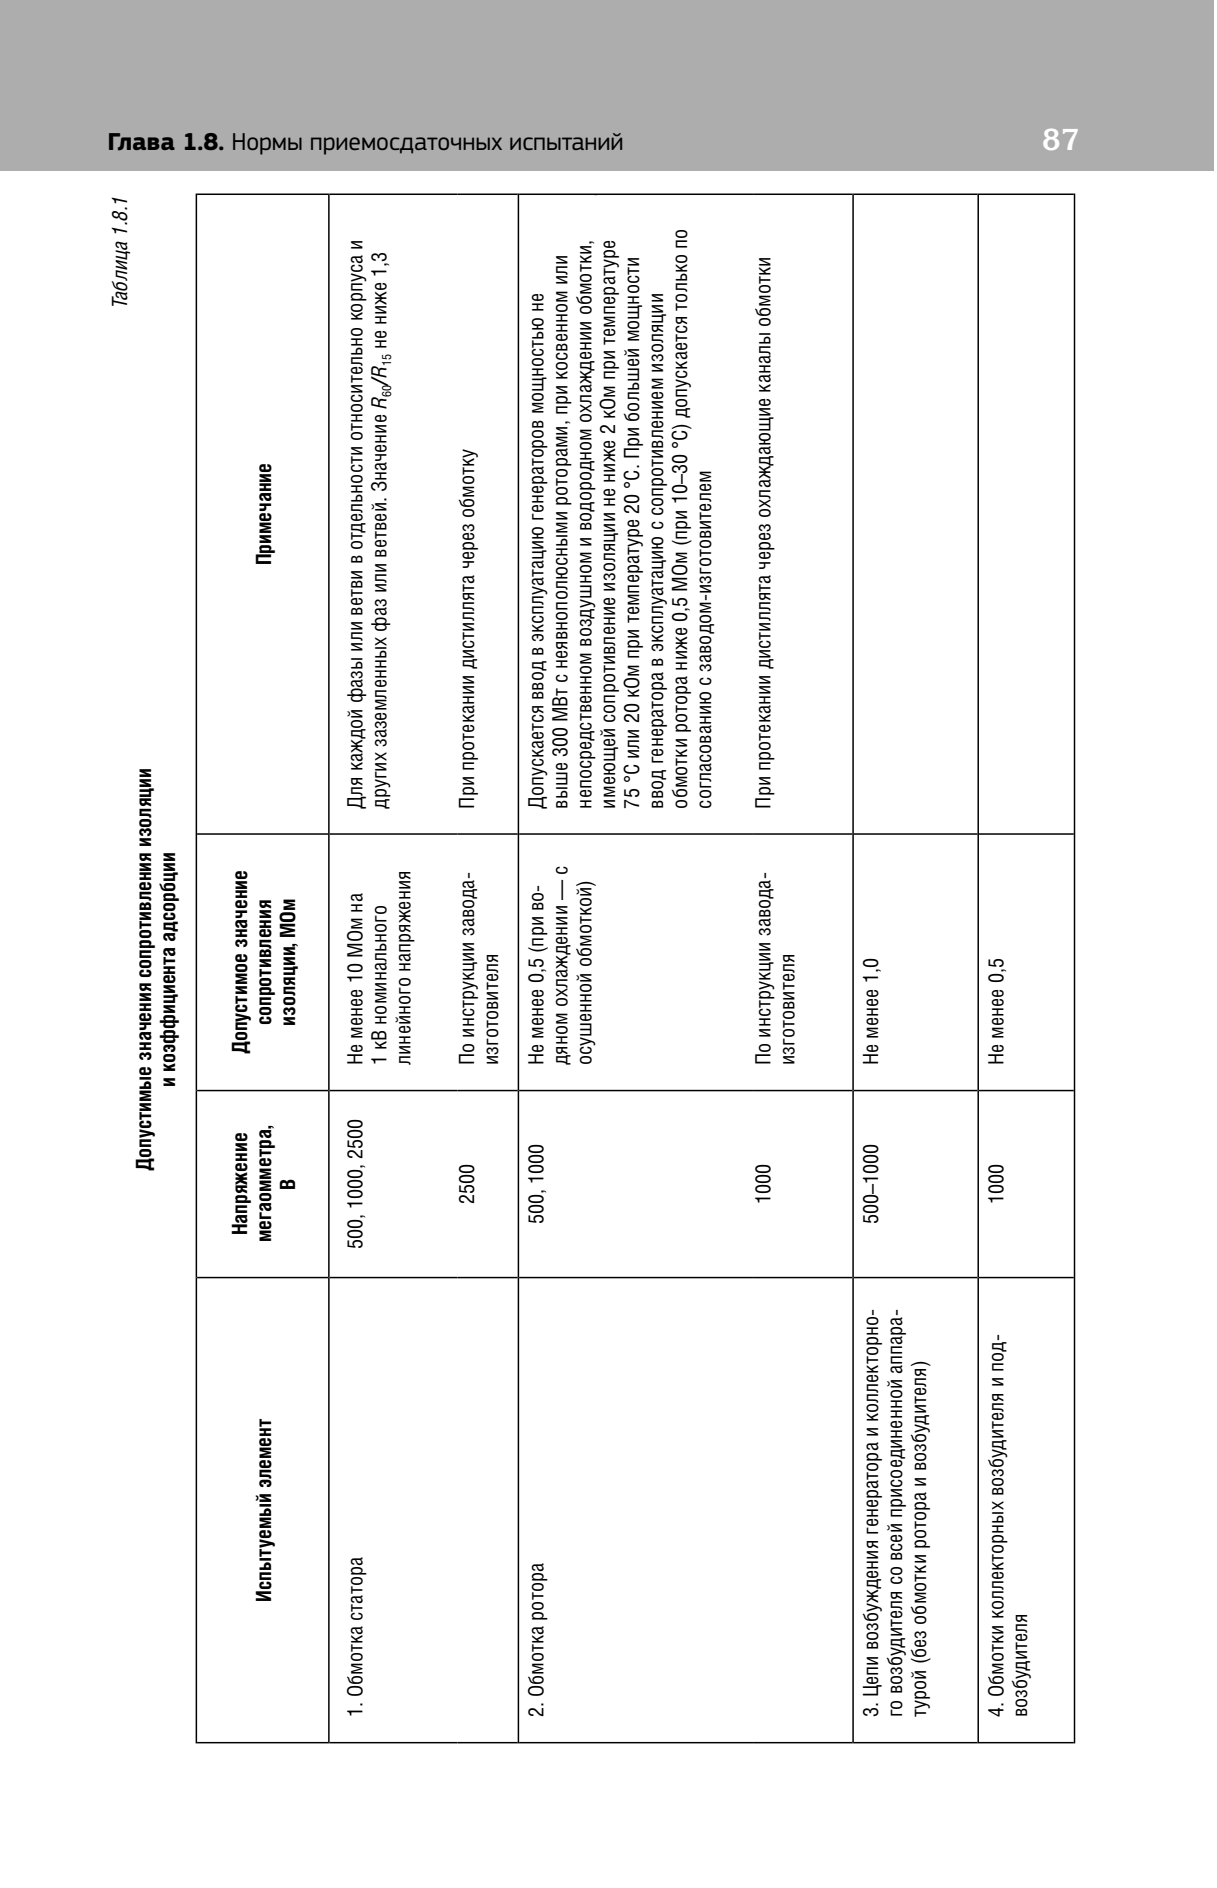

In [17]:
logger.info(f"Starting image extraction  from {pdf_file.name}...")

# Extract the target page as a PNG image
target_image = extract_page_image(
    pdf_path=pdf_file, 
    output_dir=page_images_dir
)

logger.info("Image extraction complete. Rendering preview...")

# Display the extracted image inline
display(Image(filename=target_image, width=800))

## Preparing Inputs for the Vision-Language Model (VLM)
Loading the saved Markdown into memory and converting the target image into a base64 string required by the OpenAI API spec.

In [18]:
# Load raw text
raw_markdown = raw_markdown_file.read_text(encoding="utf-8")
logger.info(f"Loaded raw Markdown: {len(raw_markdown)} characters.")

# Convert image to Base64
base64_image = encode_image_to_base64(target_image)
logger.info("Page image successfully encoded to Base64.")

2026-05-05 18:23:20 |     INFO | 004_additional_testing_cases_2:2864798789.py:3 - Loaded raw Markdown: 4894 characters.
2026-05-05 18:23:20 |     INFO | 004_additional_testing_cases_2:2864798789.py:7 - Page image successfully encoded to Base64.


## Agent Inference with Tagged Source Data
Now that we have the tagged text (Tagged MD), we send it to the VLM. We use a Native CoT approach (without rigid JSON-CoT) because the tags already provide the model with an excellent structure for maintaining focus.

In [ ]:
import os
from openai import OpenAI
from pydantic import BaseModel, Field
from typing import List

# Setup API Client (assuming dotenv is loaded at the top of notebook)
client = OpenAI(
    api_key=os.environ.get("NANOGPT_API_KEY"),
    base_url=os.environ.get("NANOGPT_BASE_URL") 
)

TARGET_MODEL = "openai/gpt-5-mini" # The main model
# TARGET_MODEL = "google/gemini-flash-latest"
# TARGET_MODEL = "google/gemini-flash-lite-latest"
# TARGET_MODEL = "openai/gpt-5.4-nano"
# TARGET_MODEL = "Qwen/Qwen3.6-35B-A3B"
# TARGET_MODEL = "moonshotai/kimi-k2.6:thinking"
# TARGET_MODEL = "gemini-2.5-flash-preview-09-2025"
# TARGET_MODEL = "openai/gpt-5.4-mini"
# Use Native CoT prompt
prompt_file_cot = notebook_root / "prompts" / "semantic_normalization_native_cot_tagged.md"
system_prompt_cot = prompt_file_cot.read_text(encoding="utf-8")

class NormalizationResultLight(BaseModel):
    clean_markdown: str = Field(
        description="Final, structurally corrected Markdown text WITHOUT any XML tags."
    )

logger.info("Pydantic schema and prompts updated for Tagged processing.")

2026-05-05 18:23:20 |     INFO | 004_additional_testing_cases_2:1243371500.py:29 - Pydantic schema and prompts updated for Tagged processing.


In [ ]:
from utils.encode_image import encode_image_to_base64
from utils.display_diff import display_diff

# Encode image
target_image = page_images_dir / f"{pdf_file.stem}_highres.png"
base64_image = encode_image_to_base64(target_image)

logger.info(f"Initiating inference with Tagged MD using model: {TARGET_MODEL}")

try:
    messages = [
        {"role": "system", "content": system_prompt_cot},
        {
            "role": "user",
            "content": [
                {
                    "type": "text", 
                    "text": f"Raw Tagged Markdown for processing:\n\n{tagged_content}"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{base64_image}",
                        "detail": "high"
                    }
                }
            ]
        }
    ]

    response = client.chat.completions.parse(
        model=TARGET_MODEL,
        messages=messages,
        temperature=0.0,
        response_format=NormalizationResultLight,
    )

    tagged_normalized_data = response.choices[0].message.parsed
    logger.info("Inference complete. Checking output...")
    
    # Save the result
    processed_dir = notebook_root / "data" / "03_processed"
    final_output_file = processed_dir / f"{pdf_file.stem}_clean_tagged.md"
    final_output_file.write_text(tagged_normalized_data.clean_markdown, encoding="utf-8")
    
    logger.info(f"Saved to: {final_output_file.name}")

    # Visual Diff: Compare the raw md-file (no tags) and the cleaned md-file
    raw_untagged_md = raw_markdown_file.read_text(encoding="utf-8")
    
    display_diff(
        text_before=raw_untagged_md, 
        text_after=tagged_normalized_data.clean_markdown,
        fromfile='Raw_Docling_Untagged',
        tofile='LLM_Healed_via_Tags'
    )

except Exception as e:
    logger.error(f"Inference failed. Error: {e}", exc_info=True)

2026-05-05 18:23:20 |     INFO | 004_additional_testing_cases_2:3722612486.py:8 - Initiating inference with Tagged MD using model: openai/gpt-5-mini
2026-05-05 18:23:57 |     INFO | 004_additional_testing_cases_2:3722612486.py:39 - Inference complete. Checking output...
2026-05-05 18:23:57 |     INFO | 004_additional_testing_cases_2:3722612486.py:46 - Saved to: one_page_horizontal_table_clean_tagged.md


```diff
--- Raw_Docling_Untagged
+++ LLM_Healed_via_Tags
@@ -1,19 +1,9 @@
-изоляции
+## Глава 1.8. Нормы приемосдаточных испытаний
 
-сопротивления
+### Допустимые значения сопротивления изоляции и коэффициента адсорбции
 
-значения
-
-Допустимые
-
-адсорбции
-
-коэффициента
-
-и
-
-| Примечание                                       | Для каждой фазы или ветви в отдельности относительно корпуса и других заземленных фаз или ветвей . Значение R 60 / R 15 не ниже 1,3   | При протекании дистиллята через обмотку   | Допускается ввод в эксплуатацию генераторов мощностью не выше 300 МВт с неявнополюсными роторами , при косвенном или непосредственном воздушном и водородном охлаждении обмотки , имеющей сопротивление изоляции не ниже 2 кОм при температуре 75 ° С или 20 кОм при температуре 20 ° С . При большей мощности ввод генератора в эксплуатацию с сопротивлением изоляции обмотки ротора ниже 0,5 МОм ( при 10-30 ° С ) допускается только по согласованию с заводом - изготовителем   | При протекании дистиллята через охлаждающие каналы обмотки   |                                                                                                                                          |                                                         |
-|--------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------|
-| Допустимое значение сопротивления изоляции , МОм | Не менее 10 МОм на 1 кВ номинального линейного напряжения                                                                             | По инструкции завода - изготовителя       | Не менее 0,5 ( при во - дяном охлаждении - с осушенной обмоткой )                                                                                                                                                                                                                                                                                                                                                                                                                    | По инструкции завода - изготовителя                          | Не менее 1,0                                                                                                                             | Не менее 0,5                                            |
-| Напряжение мегаомметра , В                       | 500, 1000, 2500                                                                                                                       | 2500                                      | 500, 1000                                                                                                                                                                                                                                                                                                                                                                                                                                                                            | 1000                                                         | 500-1000                                                                                                                                 | 1000                                                    |
-| Испытуемый элемент                               | 1. Обмотка статора                                                                                                                    |                                           | 2. Обмотка ротора                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |                                                              | 3. Цепи возбуждения генератора и коллекторно - го возбудителя со всей присоединенной аппара - турой ( без обмотки ротора и возбудителя ) | 4. Обмотки коллекторных возбудителя и под - возбудителя |
+| Примечание | Для каждой фазы или ветви в отдельности относительно корпуса и других заземленных фаз или ветвей. Значение $R_{60}/R_{15}$ не ниже 1,3 | При протекании дистиллята через обмотку | Допускается ввод в эксплуатацию генераторов мощностью не выше 300 МВт с неявнополюсными роторами, при косвенном или непосредственном воздушном и водородном охлаждении обмотки, имеющей сопротивление изоляции не ниже 2 кОм при температуре 75 °C или 20 кОм при температуре 20 °C. При большей мощности ввод генератора в эксплуатацию с сопротивлением изоляции обмотки ротора ниже 0,5 МОм (при 10–30 °C) допускается только по согласованию с заводом-изготовителем | При протекании дистиллята через охлаждающие каналы обмотки |  |  |
+|:---|:---|:---|:---|:---|:---|:---|
+| Допустимое значение сопротивления изоляции, МОм | Не менее 10 МОм на 1 кВ номинального линейного напряжения | По инструкции завода-изготовителя | Не менее 0,5 (при водяном охлаждении — с осушенной обмоткой) | По инструкции завода-изготовителя | Не менее 1,0 | Не менее 0,5 |
+| Напряжение мегаомметра, В | 500, 1000, 2500 | 2500 | 500, 1000 | 1000 | 500–1000 | 1000 |
+| Испытуемый элемент | 1. Обмотка статора |  | 2. Обмотка ротора |  | 3. Цепи возбуждения генератора и коллекторного возбудителя со всей присоединенной аппаратурой (без обмотки ротора и возбудителя) | 4. Обмотки коллекторных возбудителя и подвозбудителя |
```

## Output

The final output is poor and has a lot of issues. We do not touch our prevous prompt but rotate the original image on 90 degrees to simplify the task for docling.

<div style="border: 2px solid #388e3c; border-radius: 8px; padding: 20px; background-color: rgba(56, 142, 60, 0.05); box-shadow: 0 4px 6px rgba(0,0,0,0.05); width: fit-content;">

<h3 style="margin-top: 0; color: #388e3c; border-bottom: 1px solid #388e3c; padding-bottom: 8px;">
  📄 Output
</h3>

изоляции

сопротивления

значения

Допустимые

адсорбции

коэффициента

и

| Примечание                                       | Для каждой фазы или ветви в отдельности относительно корпуса и других заземленных фаз или ветвей . Значение R 60 / R 15 не ниже 1,3   | При протекании дистиллята через обмотку   | Допускается ввод в эксплуатацию генераторов мощностью не выше 300 МВт с неявнополюсными роторами , при косвенном или непосредственном воздушном и водородном охлаждении обмотки , имеющей сопротивление изоляции не ниже 2 кОм при температуре 75 ° С или 20 кОм при температуре 20 ° С . При большей мощности ввод генератора в эксплуатацию с сопротивлением изоляции обмотки ротора ниже 0,5 МОм ( при 10-30 ° С ) допускается только по согласованию с заводом - изготовителем   | При протекании дистиллята через охлаждающие каналы обмотки   |                                                                                                                                          |                                                         |
|--------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------|
| Допустимое значение сопротивления изоляции , МОм | Не менее 10 МОм на 1 кВ номинального линейного напряжения                                                                             | По инструкции завода - изготовителя       | Не менее 0,5 ( при во - дяном охлаждении - с осушенной обмоткой )                                                                                                                                                                                                                                                                                                                                                                                                                    | По инструкции завода - изготовителя                          | Не менее 1,0                                                                                                                             | Не менее 0,5                                            |
| Напряжение мегаомметра , В                       | 500, 1000, 2500                                                                                                                       | 2500                                      | 500, 1000                                                                                                                                                                                                                                                                                                                                                                                                                                                                            | 1000                                                         | 500-1000                                                                                                                                 | 1000                                                    |
| Испытуемый элемент                               | 1. Обмотка статора                                                                                                                    |                                           | 2. Обмотка ротора                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |                                                              | 3. Цепи возбуждения генератора и коллекторно - го возбудителя со всей присоединенной аппара - турой ( без обмотки ротора и возбудителя ) | 4. Обмотки коллекторных возбудителя и под - возбудителя |

</div>